In [8]:
import os
import re
import json
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from pathlib import Path

BASE_DIR = Path(os.getcwd())

# Mosaic

In [9]:
MOSAIC_INPUT = BASE_DIR / "datasets" / "Mosaic" / "patient"
MOSAIC_OUTPUT = BASE_DIR / "data_all"

os.makedirs(MOSAIC_OUTPUT, exist_ok=True)

records = []

for patient_folder in sorted(os.listdir(MOSAIC_INPUT)):
    patient_path = os.path.join(MOSAIC_INPUT, patient_folder)
    if not os.path.isdir(patient_path):
        continue

    patient_num = patient_folder.replace("Patient ", "").strip()

    for eye_folder in os.listdir(patient_path):
        eye_path = os.path.join(patient_path, eye_folder)
        if not os.path.isdir(eye_path):
            continue

        eye = eye_folder.strip()

        for filename in os.listdir(eye_path):
            if "disc" in filename.lower():
                continue

            ext = os.path.splitext(filename)[1].lower()
            if ext not in [".jpeg", ".jpg", ".png"]:
                continue

            img_path = os.path.join(eye_path, filename)

            try:
                img = Image.open(img_path).convert("RGB")
                width, height = img.size
            except Exception as e:
                print(f"Cannot open {img_path}: {e}")
                continue

            stem = os.path.splitext(filename)[0]

            sample_id  = f"Mosaic_Patient {patient_num}_{eye}_{stem}"
            patient_id = f"{patient_num}_{eye}_{stem}"
            out_path   = f"data_all/Patient {patient_num}_{eye}_{stem}.png"  

            img.save(out_path)

            records.append({
                "sample_id":         sample_id,
                "dataset":           "Mosaic",           
                "patient_id":        patient_id,
                "image_path":        out_path,
                "original_filename": filename,
                "modality":          "SVP",
                "disease":           float("nan"),
                "scan_protocol":     "6x6",
                "width":             width,
                "height":            height,
                "quality":           float("nan"),
                "faz_applied":       False,
            })

df_mosaic = pd.DataFrame(records)
print(f"MOSAIC: {len(df_mosaic)} spracovaných snímok")
df_mosaic.head()

MOSAIC: 52 spracovaných snímok


,sample_id,dataset,patient_id,image_path,original_filename,modality,disease,scan_protocol,width,height,quality,faz_applied
0,Mosaic_Patient 1_left eye_angio6centersup,Mosaic,1_left eye_angio6centersup,data_all/Patient 1_left eye_angio6centersup.png,angio6centersup.jpeg,SVP,NaN,6x6,320,320,NaN,False
1,Mosaic_Patient 1_left eye_angio6macsup,Mosaic,1_left eye_angio6macsup,data_all/Patient 1_left eye_angio6macsup.png,angio6macsup.jpeg,SVP,NaN,6x6,320,320,NaN,False
2,Mosaic_Patient 1_right eye_angio6centersup,Mosaic,1_right eye_angio6centersup,data_all/Patient 1_right eye_angio6centersup.png,angio6centersup.jpeg,SVP,NaN,6x6,320,320,NaN,False
3,Mosaic_Patient 1_right eye_angio6macsup,Mosaic,1_right eye_angio6macsup,data_all/Patient 1_right eye_angio6macsup.png,angio6macsup.jpeg,SVP,NaN,6x6,320,320,NaN,False
4,Mosaic_Patient 10_left eye_angio6centersup,Mosaic,10_left eye_angio6centersup,data_all/Patient 10_left eye_angio6centersup.png,angio6centersup.jpeg,SVP,NaN,6x6,320,320,NaN,False


# SOUL

In [10]:
SOUL_INPUT  = BASE_DIR / "datasets" / "Soul"
SOUL_OUTPUT = BASE_DIR / "data_all"
os.makedirs(SOUL_OUTPUT, exist_ok=True)

records = []

for s_folder in sorted(os.listdir(SOUL_INPUT)):
    s_path = os.path.join(SOUL_INPUT, s_folder)
    if not os.path.isdir(s_path):
        continue

    for t_folder in sorted(os.listdir(s_path)):
        t_path = os.path.join(s_path, t_folder)
        if not os.path.isdir(t_path):
            continue

        image_path = os.path.join(t_path, "image")
        if not os.path.isdir(image_path):
            continue

        for patient_folder in sorted(os.listdir(image_path)):
            patient_path = os.path.join(image_path, patient_folder)
            if not os.path.isdir(patient_path):
                continue

            for filename in sorted(os.listdir(patient_path)):
                ext = os.path.splitext(filename)[1].lower()
                if ext not in [".jpg", ".jpeg", ".png"]:
                    continue

                full_path = os.path.join(patient_path, filename)
                stem      = os.path.splitext(filename)[0]

                sample_id  = f"Soul_{s_folder}_{t_folder}_image_{patient_folder}_{stem}"
                patient_id = f"{s_folder}_{patient_folder}_{stem}"  
                out_path   = f"data_all/{s_folder}_{t_folder}_image_{patient_folder}_{stem}.png"  

                try:
                    img = Image.open(full_path).convert("RGB")
                    width, height = img.size
                    img.save(out_path)
                except Exception as e:
                    print(f"Cannot open {full_path}: {e}")
                    continue

                records.append({
                    "sample_id":         sample_id,
                    "dataset":           "Soul",           
                    "patient_id":        patient_id,
                    "image_path":        out_path,
                    "original_filename": filename,
                    "modality":          "SVP",
                    "disease":           "BRVO",
                    "scan_protocol":     "6x6",
                    "width":             width,
                    "height":            height,
                    "quality":           float("nan"),
                    "faz_applied":       False,
                })

df_soul = pd.DataFrame(records)
print(f"SOUL: {len(df_soul)} spracovaných snímok")
df_soul.head()

SOUL: 1023 spracovaných snímok


,sample_id,dataset,patient_id,image_path,original_filename,modality,disease,scan_protocol,width,height,quality,faz_applied
0,Soul_S1_s1t1_image_1_1_11422,Soul,S1_1_1_11422,data_all/S1_s1t1_image_1_1_11422.png,1_11422.jpg,SVP,BRVO,6x6,304,304,NaN,False
1,Soul_S1_s1t1_image_1_1_11571,Soul,S1_1_1_11571,data_all/S1_s1t1_image_1_1_11571.png,1_11571.jpg,SVP,BRVO,6x6,304,304,NaN,False
2,Soul_S1_s1t1_image_1_1_12538,Soul,S1_1_1_12538,data_all/S1_s1t1_image_1_1_12538.png,1_12538.jpg,SVP,BRVO,6x6,304,304,NaN,False
3,Soul_S1_s1t1_image_1_1_12746,Soul,S1_1_1_12746,data_all/S1_s1t1_image_1_1_12746.png,1_12746.jpg,SVP,BRVO,6x6,304,304,NaN,False
4,Soul_S1_s1t1_image_10_10_11893,Soul,S1_10_10_11893,data_all/S1_s1t1_image_10_10_11893.png,10_11893.jpg,SVP,BRVO,6x6,304,304,NaN,False


# FAZID

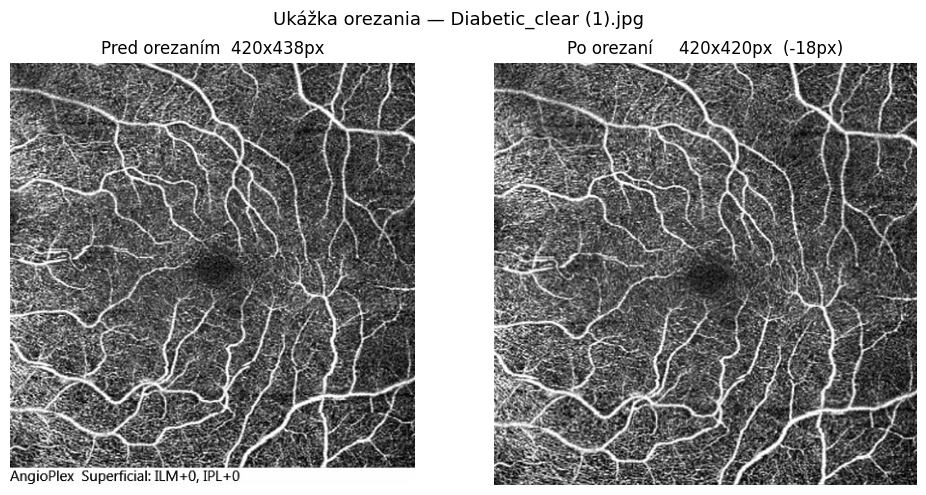

FAZID: 304 spracovaných snímok


,sample_id,dataset,patient_id,image_path,original_filename,modality,disease,scan_protocol,width,height,quality,faz_applied
0,Fazid_Diabetic_1,Fazid,Diabetic_1,data_all/Diabetic_clear (1).png,Diabetic_clear (1).jpg,SVP,DR,6x6,420,420,NaN,False
1,Fazid_Diabetic_10,Fazid,Diabetic_10,data_all/Diabetic_clear (10).png,Diabetic_clear (10).jpg,SVP,DR,6x6,412,412,NaN,False
2,Fazid_Diabetic_100,Fazid,Diabetic_100,data_all/Diabetic_clear (100).png,Diabetic_clear (100).jpg,SVP,DR,6x6,412,412,NaN,False
3,Fazid_Diabetic_101,Fazid,Diabetic_101,data_all/Diabetic_clear (101).png,Diabetic_clear (101).jpg,SVP,DR,6x6,412,412,NaN,False
4,Fazid_Diabetic_102,Fazid,Diabetic_102,data_all/Diabetic_clear (102).png,Diabetic_clear (102).jpg,SVP,DR,6x6,420,420,NaN,False


In [11]:
FAZID_INPUT  = BASE_DIR / "datasets" / "Fazid"
FAZID_OUTPUT = BASE_DIR / "data_all"

os.makedirs(FAZID_OUTPUT, exist_ok=True)

DISEASE_MAP = {
    "Diabetic": "DR",
    "Myopia":   "Myopia",
    "Normal":   "Healthy",
}

CROP_BOTTOM = 18
preview_done = False
records = []

for disease_folder, disease_label in DISEASE_MAP.items():
    clear_path = os.path.join(FAZID_INPUT, disease_folder, "Clear")
    if not os.path.isdir(clear_path):
        clear_path = os.path.join(FAZID_INPUT, disease_folder)

    for filename in sorted(os.listdir(clear_path)):
        ext = os.path.splitext(filename)[1].lower()
        if ext not in [".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"]:
            continue

        full_path = os.path.join(clear_path, filename)

        match = re.search(r"\((\d+)\)", filename)
        if not match:
            print(f"Preskočené (nenašlo číslo): {filename}")
            continue
        img_num = match.group(1)

        stem = os.path.splitext(filename)[0]  

        sample_id  = f"Fazid_{disease_folder}_{img_num}"
        patient_id = f"{disease_folder}_{img_num}"
        out_path   = f"data_all/{stem}.png"  

        try:
            img = Image.open(full_path).convert("RGB")
            img_cropped = img.crop((0, 0, img.width, img.height - CROP_BOTTOM))
            width, height = img_cropped.size
            img_cropped.save(out_path)
        except Exception as e:
            print(f"Cannot open {full_path}: {e}")
            continue

        if not preview_done:
            fig, axes = plt.subplots(1, 2, figsize=(10, 5))
            axes[0].imshow(img)
            axes[0].set_title(f"Pred orezaním  {img.size[0]}x{img.size[1]}px", fontsize=12)
            axes[1].imshow(img_cropped)
            axes[1].set_title(f"Po orezaní     {width}x{height}px  (-{CROP_BOTTOM}px)", fontsize=12)
            for ax in axes:
                ax.axis("off")
            fig.suptitle(f"Ukážka orezania — {filename}", fontsize=13)
            plt.tight_layout()
            plt.show()
            preview_done = True

        records.append({
            "sample_id":         sample_id,
            "dataset":           "Fazid",           
            "patient_id":        patient_id,
            "image_path":        out_path,
            "original_filename": filename,
            "modality":          "SVP",
            "disease":           disease_label,
            "scan_protocol":     "6x6",
            "width":             width,
            "height":            height,
            "quality":           float("nan"),
            "faz_applied":       False,
        })

df_fazid = pd.DataFrame(records)
print(f"FAZID: {len(df_fazid)} spracovaných snímok")
df_fazid.head()

# OCTAGON

In [12]:
OCTAGON_DIABETIC = BASE_DIR / "datasets" / "Octagon" / "diabetic"
OCTAGON_HEALTHY  = BASE_DIR / "datasets" / "Octagon" / "health_labeled"
OCTAGON_OUTPUT   = BASE_DIR / "data_all"
OCTAGON_DAMAGED  = BASE_DIR / "octagon_damaged"

os.makedirs(OCTAGON_OUTPUT,  exist_ok=True)
os.makedirs(OCTAGON_DAMAGED, exist_ok=True)

records = []

def get_modality(filename):
    name_lower = filename.lower()
    if "superf" in name_lower:
        return "SVP"
    elif "prof" in name_lower:
        return "DCP"
    return None

def process_image(full_path, sample_id, out_path, disease):
    try:
        img = Image.open(full_path).convert("RGB")
        width, height = img.size
        img.save(out_path)
        return out_path, width, height, False
    except Exception as e:
        print(f"Poškodený snímok: {full_path} → {e}")
        damaged_path = os.path.join(OCTAGON_DAMAGED, os.path.basename(out_path))
        shutil.copy2(full_path, damaged_path)
        return damaged_path, None, None, True

for filename in sorted(os.listdir(OCTAGON_DIABETIC)):
    ext = os.path.splitext(filename)[1].lower()
    if ext not in [".jpg", ".jpeg", ".png", ".tif", ".tiff"]:
        continue

    name_lower = filename.lower()
    if "6"       not in name_lower:                                      continue
    if "superf"  not in name_lower and "prof" not in name_lower:         continue
    if "manual"  in name_lower:                                          continue
    if "area6"   in name_lower:                                          continue

    stem     = os.path.splitext(filename)[0]
    modality = get_modality(filename)

    match      = re.match(r"(paciente\d+)", stem)
    patient_id = match.group(1) if match else stem
    sample_id  = f"Octagon_{stem}"
    out_path   = f"data_all/{stem}.png" 

    full_path = os.path.join(OCTAGON_DIABETIC, filename)
    out_path, width, height, damaged = process_image(full_path, sample_id, out_path, "DR")

    records.append({
        "sample_id":         sample_id,
        "dataset":           "Octagon",
        "patient_id":        patient_id,
        "image_path":        out_path,
        "original_filename": filename,
        "modality":          modality,
        "disease":           "DR",
        "scan_protocol":     "6x6",
        "width":             width,
        "height":            height,
        "quality":           float("nan"),
        "faz_applied":       False,
        "damaged":           damaged,
    })

for age_group in sorted(os.listdir(OCTAGON_HEALTHY)):
    age_path = os.path.join(OCTAGON_HEALTHY, age_group)
    if not os.path.isdir(age_path):
        continue

    for subj in sorted(os.listdir(age_path)):
        subj_path = os.path.join(age_path, subj)
        if not os.path.isdir(subj_path):
            continue

        for eye in sorted(os.listdir(subj_path)):
            eye_path = os.path.join(subj_path, eye)
            if not os.path.isdir(eye_path):
                continue

            eye_short     = eye.replace("ojo ", "").strip()
            eye_underscored = eye.replace(" ", "_")  

            for filename in sorted(os.listdir(eye_path)):
                ext = os.path.splitext(filename)[1].lower()
                if ext not in [".jpg", ".jpeg", ".png", ".tif", ".tiff"]:
                    continue

                name_lower = filename.lower()
                if "6"      not in name_lower:                               continue
                if "superf" not in name_lower and "prof" not in name_lower:  continue
                if "manual" in name_lower:                                   continue
                if "area6"  in name_lower:                                   continue

                stem     = os.path.splitext(filename)[0]
                modality = get_modality(filename)

                patient_id = f"{age_group}_{subj}_{eye_short}"
                sample_id  = f"Octagon_{age_group}_{subj}_{eye_short}_{stem}"
                out_path   = f"data_all/{stem}_{age_group}_{subj}_{eye_underscored}.png"  

                full_path = os.path.join(eye_path, filename)
                out_path, width, height, damaged = process_image(full_path, sample_id, out_path, "Healthy")

                records.append({
                    "sample_id":         sample_id,
                    "dataset":           "Octagon",
                    "patient_id":        patient_id,
                    "image_path":        out_path,
                    "original_filename": filename,
                    "modality":          modality,
                    "disease":           "Healthy",
                    "scan_protocol":     "6x6",
                    "width":             width,
                    "height":            height,
                    "quality":           float("nan"),
                    "faz_applied":       False,
                    "damaged":           damaged,
                })

df_octagon = pd.DataFrame(records)

print(f"OCTAGON: {len(df_octagon)} spracovaných snímok")
print(f"  DR:      {len(df_octagon[df_octagon.disease == 'DR'])}")
print(f"  Healthy: {len(df_octagon[df_octagon.disease == 'Healthy'])}")
print(f"  Poškodených: {len(df_octagon[df_octagon.damaged == True])}")
df_octagon.head(10)

Poškodený snímok: C:\Users\klara\Desktop\Fianl\01_Data_Preprocessing\datasets\Octagon\health_labeled\10-19\1\ojo derecho\angio6prof.tif → cannot identify image file 'C:\\Users\\klara\\Desktop\\Fianl\\01_Data_Preprocessing\\datasets\\Octagon\\health_labeled\\10-19\\1\\ojo derecho\\angio6prof.tif'
Poškodený snímok: C:\Users\klara\Desktop\Fianl\01_Data_Preprocessing\datasets\Octagon\health_labeled\10-19\1\ojo derecho\angio6superf.tif → cannot identify image file 'C:\\Users\\klara\\Desktop\\Fianl\\01_Data_Preprocessing\\datasets\\Octagon\\health_labeled\\10-19\\1\\ojo derecho\\angio6superf.tif'
Poškodený snímok: C:\Users\klara\Desktop\Fianl\01_Data_Preprocessing\datasets\Octagon\health_labeled\10-19\1\ojo izquierdo\angio6prof.tif → cannot identify image file 'C:\\Users\\klara\\Desktop\\Fianl\\01_Data_Preprocessing\\datasets\\Octagon\\health_labeled\\10-19\\1\\ojo izquierdo\\angio6prof.tif'
Poškodený snímok: C:\Users\klara\Desktop\Fianl\01_Data_Preprocessing\datasets\Octagon\health_labeled\

,sample_id,dataset,patient_id,image_path,original_filename,modality,disease,scan_protocol,width,height,quality,faz_applied,damaged
0,Octagon_paciente11_mm6_superf,Octagon,paciente11,data_all/paciente11_mm6_superf.png,paciente11_mm6_superf.jpg,SVP,DR,6x6,320.0,320.0,NaN,False,False
1,Octagon_paciente12_mm6_prof,Octagon,paciente12,data_all/paciente12_mm6_prof.png,paciente12_mm6_prof.jpg,DCP,DR,6x6,320.0,320.0,NaN,False,False
2,Octagon_paciente13_mm6_prof,Octagon,paciente13,data_all/paciente13_mm6_prof.png,paciente13_mm6_prof.jpg,DCP,DR,6x6,320.0,320.0,NaN,False,False
3,Octagon_paciente1_mm6_superf,Octagon,paciente1,data_all/paciente1_mm6_superf.png,paciente1_mm6_superf.jpg,SVP,DR,6x6,320.0,320.0,NaN,False,False
4,Octagon_paciente21_mm6_prof,Octagon,paciente21,data_all/paciente21_mm6_prof.png,paciente21_mm6_prof.jpg,DCP,DR,6x6,320.0,320.0,NaN,False,False
5,Octagon_paciente22_mm6_prof,Octagon,paciente22,data_all/paciente22_mm6_prof.png,paciente22_mm6_prof.jpg,DCP,DR,6x6,320.0,320.0,NaN,False,False
6,Octagon_paciente23_mm6_superf,Octagon,paciente23,data_all/paciente23_mm6_superf.png,paciente23_mm6_superf.jpg,SVP,DR,6x6,320.0,320.0,NaN,False,False
7,Octagon_paciente26_mm6_prof,Octagon,paciente26,data_all/paciente26_mm6_prof.png,paciente26_mm6_prof.jpg,DCP,DR,6x6,320.0,320.0,NaN,False,False
8,Octagon_paciente27_mm6_superf,Octagon,paciente27,data_all/paciente27_mm6_superf.png,paciente27_mm6_superf.jpg,SVP,DR,6x6,320.0,320.0,NaN,False,False
9,Octagon_paciente28_mm6_prof,Octagon,paciente28,data_all/paciente28_mm6_prof.png,paciente28_mm6_prof.jpg,DCP,DR,6x6,320.0,320.0,NaN,False,False


# OCTA-500

In [13]:
OCTA500_SVP    = BASE_DIR / "datasets" / "OCTA_500" / "OCTA(ILM_OPL)"
OCTA500_DCP    = BASE_DIR / "datasets" / "OCTA_500" / "OCTA(OPL_BM)"
OCTA500_EXCEL  = BASE_DIR / "datasets" / "OCTA_500" / "OCTA_6mm_labels.xlsx"
OCTA500_OUTPUT = BASE_DIR / "data_all"
os.makedirs(OCTA500_OUTPUT, exist_ok=True)

df_labels = pd.read_excel(OCTA500_EXCEL)
df_labels["ID"] = df_labels["ID"].astype(str)
df_labels = df_labels.set_index("ID")

LAYERS = [
    (OCTA500_SVP, "SVP", "superf"),
    (OCTA500_DCP, "DCP", "prof"),
]

records = []

for folder, modality, layer_suffix in LAYERS:
    for filename in sorted(os.listdir(folder)):
        ext = os.path.splitext(filename)[1].lower()
        if ext not in [".bmp", ".jpg", ".jpeg", ".png"]:
            continue

        stem      = os.path.splitext(filename)[0]
        full_path = os.path.join(folder, filename)
        disease   = df_labels.loc[stem, "Disease"] if stem in df_labels.index else float("nan")
        sample_id = f"OCTA-500_{stem}_{layer_suffix}"
        out_path  = f"data_all/{stem}_{layer_suffix}.png"  

        try:
            img = Image.open(full_path).convert("RGB")
            width, height = img.size
            img.save(out_path)
        except Exception as e:
            continue

        records.append({
            "sample_id":         sample_id,
            "dataset":           "OCTA-500",        
            "patient_id":        stem,
            "image_path":        out_path,
            "original_filename": filename,
            "modality":          modality,
            "disease":           disease,
            "scan_protocol":     "6x6",
            "width":             width,
            "height":            height,
            "quality":           float("nan"),
            "faz_applied":       False,
        })

df_octa500 = pd.DataFrame(records)
print(f"OCTA-500: {len(df_octa500)} spracovaných snímok")
df_octa500.head(6)

OCTA-500: 600 spracovaných snímok


,sample_id,dataset,patient_id,image_path,original_filename,modality,disease,scan_protocol,width,height,quality,faz_applied
0,OCTA-500_10001_superf,OCTA-500,10001,data_all/10001_superf.png,10001.bmp,SVP,NORMAL,6x6,400,400,NaN,False
1,OCTA-500_10002_superf,OCTA-500,10002,data_all/10002_superf.png,10002.bmp,SVP,OTHERS,6x6,400,400,NaN,False
2,OCTA-500_10003_superf,OCTA-500,10003,data_all/10003_superf.png,10003.bmp,SVP,OTHERS,6x6,400,400,NaN,False
3,OCTA-500_10004_superf,OCTA-500,10004,data_all/10004_superf.png,10004.bmp,SVP,AMD,6x6,400,400,NaN,False
4,OCTA-500_10005_superf,OCTA-500,10005,data_all/10005_superf.png,10005.bmp,SVP,DR,6x6,400,400,NaN,False
5,OCTA-500_10006_superf,OCTA-500,10006,data_all/10006_superf.png,10006.bmp,SVP,OTHERS,6x6,400,400,NaN,False


# DRAC

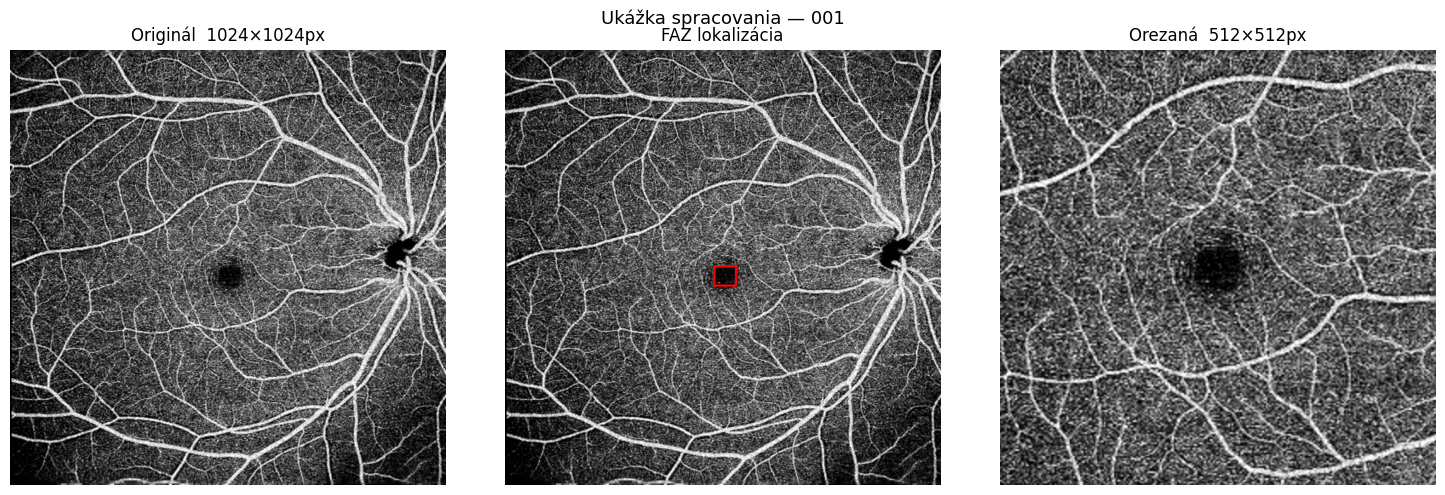

Drac : 1098 spracovaných snímok


,sample_id,dataset,patient_id,image_path,original_filename,modality,disease,scan_protocol,width,height,quality,faz_applied
0,Drac_001,Drac,001,data_all/001.png,001.png,SVP,DR,6x6,512,512,2.0,True
1,Drac_002,Drac,002,data_all/002.png,002.png,SVP,DR,6x6,512,512,2.0,True
2,Drac_003,Drac,003,data_all/003.png,003.png,SVP,DR,6x6,512,512,1.0,True
3,Drac_004,Drac,004,data_all/004.png,004.png,SVP,DR,6x6,512,512,2.0,True
4,Drac_005,Drac,005,data_all/005.png,005.png,SVP,DR,6x6,512,512,2.0,True


In [14]:
DRAC_TRAIN   = BASE_DIR / "datasets" / "DRAC" / "B. Image Quality Assessment" / "B. Image Quality Assessment" / "1. Original Images" / "a. Training Set"
DRAC_TEST    = BASE_DIR / "datasets" / "DRAC" / "B. Image Quality Assessment" / "B. Image Quality Assessment" / "1. Original Images" / "b. Testing Set"
DRAC_CSV     = BASE_DIR / "datasets" / "DRAC" / "B. Image Quality Assessment" / "B. Image Quality Assessment" / "2. Groundtruths" / "a. DRAC2022_ Image Quality Assessment_Training Labels.csv"
DRAC_FAZ_DIR = BASE_DIR / "datasets" / "DRAC" / "DRAC_FAZ"
DRAC_OUTPUT  = BASE_DIR / "data_all"

os.makedirs(DRAC_OUTPUT, exist_ok=True)

df_quality = pd.read_csv(DRAC_CSV)
df_quality["stem"] = df_quality["image name"].str.replace(".png", "", regex=False)
df_quality = df_quality.set_index("stem")

def crop_around_faz(original_cv, faz_mask_cv):
    _, binary = cv2.threshold(faz_mask_cv, 127, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    h, w = original_cv.shape[:2]

    if len(contours) == 0:
        cx, cy = w // 2, h // 2
        faz_rect = None
    else:
        largest  = max(contours, key=cv2.contourArea)
        x, y, fw, fh = cv2.boundingRect(largest)
        scale_x  = w / faz_mask_cv.shape[1]
        scale_y  = h / faz_mask_cv.shape[0]
        x  = int(x  * scale_x);  y  = int(y  * scale_y)
        fw = int(fw * scale_x);  fh = int(fh * scale_y)
        cx = x + fw // 2;        cy = y + fh // 2
        faz_rect = (x, y, fw, fh)

    new_w, new_h = w // 2, h // 2
    x1 = max(0, cx - new_w // 2);  y1 = max(0, cy - new_h // 2)
    x2 = min(w, x1 + new_w);       y2 = min(h, y1 + new_h)
    if x2 - x1 < new_w: x1 = max(0, x2 - new_w)
    if y2 - y1 < new_h: y1 = max(0, y2 - new_h)

    return original_cv[y1:y2, x1:x2], faz_rect

def show_preview(original_cv, faz_mask_cv, cropped, stem, faz_rect):
    overlay = cv2.cvtColor(original_cv, cv2.COLOR_GRAY2RGB)
    if faz_rect is not None:
        x, y, fw, fh = faz_rect
        cv2.rectangle(overlay, (x, y), (x + fw, y + fh), (255, 0, 0), 3)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"Ukážka spracovania — {stem}", fontsize=13)
    axes[0].imshow(original_cv, cmap="gray")
    axes[0].set_title(f"Originál  {original_cv.shape[1]}×{original_cv.shape[0]}px")
    axes[1].imshow(overlay)
    axes[1].set_title("FAZ lokalizácia")
    axes[2].imshow(cropped, cmap="gray")
    axes[2].set_title(f"Orezaná  {cropped.shape[1]}×{cropped.shape[0]}px")
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

records      = []
preview_done = False

for split, folder in [("train", DRAC_TRAIN), ("test", DRAC_TEST)]:
    for filename in sorted(os.listdir(folder)):
        ext = os.path.splitext(filename)[1].lower()
        if ext not in [".png", ".jpg", ".jpeg"]:
            continue

        stem      = os.path.splitext(filename)[0]
        full_path = os.path.join(folder, filename)
        faz_path  = os.path.join(DRAC_FAZ_DIR, stem, "images", f"{stem}_FAZ_mask_0.png")

        if not os.path.exists(faz_path):
            continue

        quality = df_quality.loc[stem, "image quality level"] if stem in df_quality.index else float("nan")

        sample_id = f"Drac_{stem}"
        out_path  = f"data_all/{stem}.png"  

        try:
            original_cv = cv2.imread(full_path, cv2.IMREAD_GRAYSCALE)
            faz_mask_cv = cv2.imread(faz_path,  cv2.IMREAD_GRAYSCALE)
            cropped, faz_rect = crop_around_faz(original_cv, faz_mask_cv)
            height, width = cropped.shape[:2]
            cv2.imwrite(out_path, cropped)
        except Exception as e:
            print(f"Chyba pri {stem}: {e}")
            continue

        if not preview_done:
            show_preview(original_cv, faz_mask_cv, cropped, stem, faz_rect)
            preview_done = True

        records.append({
            "sample_id":         sample_id,
            "dataset":           "Drac",           
            "patient_id":        stem,
            "image_path":        out_path,
            "original_filename": filename,
            "modality":          "SVP",
            "disease":           "DR",
            "scan_protocol":     "6x6",
            "width":             width,
            "height":            height,
            "quality":           quality,
            "faz_applied":       True,
        })

df_drac = pd.DataFrame(records)
print(f"Drac : {len(df_drac)} spracovaných snímok")
df_drac.head()

# M3OCTA

In [15]:
M3OCTA_BASE     = BASE_DIR / "datasets" / "M3OCTA"
M3OCTA_PATIENTS = M3OCTA_BASE / "patients"
M3OCTA_FAZ_DIR  = BASE_DIR / "datasets" / "M3OCTA" / "M3OCTA_FAZ"
M3OCTA_OUTPUT   = BASE_DIR / "data_all"

os.makedirs(M3OCTA_OUTPUT, exist_ok=True)

DISEASE_LABELS = ["DR", "DME", "RVO", "HBP", "VH"]
JSON_FILES     = ["train.json", "test.json", "val.json", "pretrain.json"]

PROTOCOL_CROP = {
    "24.0x20.0": lambda w, h: int(min(w, h) * 6 / 20),
    "23.0x20.0": lambda w, h: int(min(w, h) * 6 / 20),
    "20.0x14.0": lambda w, h: int(min(w, h) * 6 / 14),
    "18.0x18.0": lambda w, h: int(min(w, h) * 6 / 18),
    "18.0x17.0": lambda w, h: int(min(w, h) * 6 / 17),
    "16.0x16.0": lambda w, h: int(min(w, h) * 6 / 16),
    "14.0x14.0": lambda w, h: int(min(w, h) * 6 / 14),
    "12.0x12.0": lambda w, h: int(min(w, h) * 6 / 12),
}

json_lookup = {}
for json_file in JSON_FILES:
    json_path = os.path.join(M3OCTA_BASE, json_file)
    if not os.path.exists(json_path):
        continue
    with open(json_path, "r") as f:
        data = json.load(f)
    for patient_num, patient_data in data.items():
        for eye in ["Right", "Right1", "Left", "Left1"]:
            if eye not in patient_data:
                continue
            eye_data = patient_data[eye]
            labels   = eye_data.get("Label", [0, 0, 0, 0, 0])
            protocol = eye_data.get("Scan_protocol", [None, None])
            diseases = [DISEASE_LABELS[i] for i, v in enumerate(labels) if v == 1]
            key = (patient_num, eye)
            if key not in json_lookup:
                json_lookup[key] = {
                    "disease": ",".join(diseases) if diseases else ("Healthy" if all(v == 0 for v in labels) else "Unknown"),                    "scan_protocol": f"{protocol[0]}x{protocol[1]}" if protocol else None,
                }

faz_lookup = {}
for folder in os.listdir(M3OCTA_FAZ_DIR):
    key = folder.replace("surface", "").lower()
    faz_lookup[key] = folder

def crop_around_faz(original_cv, mask_cv, scan_protocol):
    h, w      = original_cv.shape[:2]
    crop_fn   = PROTOCOL_CROP.get(scan_protocol)
    crop_size = crop_fn(w, h) if crop_fn else w // 2

    mask_resized = cv2.resize(mask_cv, (w, h), interpolation=cv2.INTER_NEAREST)
    _, binary    = cv2.threshold(mask_resized, 127, 255, cv2.THRESH_BINARY)
    contours, _  = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    cx, cy = (w // 2, h // 2)
    if len(contours) > 0:
        largest      = max(contours, key=cv2.contourArea)
        x, y, fw, fh = cv2.boundingRect(largest)
        cx = x + fw // 2
        cy = y + fh // 2

    x1 = max(0, cx - crop_size // 2)
    y1 = max(0, cy - crop_size // 2)
    x2 = min(w, x1 + crop_size)
    y2 = min(h, y1 + crop_size)
    if x2 - x1 < crop_size:
        x1 = max(0, x2 - crop_size)
    if y2 - y1 < crop_size:
        y1 = max(0, y2 - crop_size)

    return original_cv[y1:y2, x1:x2]

records = []
no_faz  = []

for patient_num in sorted(os.listdir(M3OCTA_PATIENTS)):
    patient_path = os.path.join(M3OCTA_PATIENTS, patient_num)
    if not os.path.isdir(patient_path):
        continue

    for eye_folder in sorted(os.listdir(patient_path)):
        eye_path = os.path.join(patient_path, eye_folder)
        if not os.path.isdir(eye_path):
            continue

        eye_base   = eye_folder.rstrip("0123456789")
        eye_num    = eye_folder[len(eye_base):]
        index      = int(eye_num) if eye_num else 0
        patient_id = f"{patient_num}_{eye_base}"

        json_data     = json_lookup.get((patient_num, eye_folder), {})
        if not json_data:
            json_data = json_lookup.get((patient_num, eye_base), {})
        if not json_data:
            json_data = json_lookup.get((patient_num, eye_base + "1"), {})
        disease       = json_data.get("disease", float("nan"))
        scan_protocol = json_data.get("scan_protocol", None)

        faz_key    = f"{patient_num}{eye_base}".lower()
        faz_folder = faz_lookup.get(faz_key)
        faz_path   = os.path.join(M3OCTA_FAZ_DIR, faz_folder, "images",
                     f"{faz_folder}_FAZ_mask_0.png") if faz_folder else None
        has_faz    = faz_path and os.path.exists(faz_path)

        for layer, modality in [("surface", "SVP"), ("deep", "DCP")]:
            img_path = os.path.join(eye_path, f"{layer}.png")
            if not os.path.exists(img_path):
                continue

            sample_id = f"M3OCTA_{patient_num}_{eye_base}_{index}_{layer}"
            out_path  = f"data_all/{layer}_{patient_num}_{eye_base}{index if index > 0 else ''}.png"

            try:
                original_cv = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if original_cv is None:
                    continue

                if has_faz:
                    mask_cv = cv2.imread(faz_path, cv2.IMREAD_GRAYSCALE)
                    cropped = crop_around_faz(original_cv, mask_cv, scan_protocol)
                else:
                    h, w      = original_cv.shape[:2]
                    crop_fn   = PROTOCOL_CROP.get(scan_protocol)
                    crop_size = crop_fn(w, h) if crop_fn else w // 2
                    x1 = (w - crop_size) // 2
                    y1 = (h - crop_size) // 2
                    cropped   = original_cv[y1:y1+crop_size, x1:x1+crop_size]
                    if layer == "surface":
                        no_faz.append(sample_id)

                cv2.imwrite(out_path, cropped)

            except Exception as e:
                print(f"Chyba pri {sample_id}: {e}")
                continue

            records.append({
                "sample_id":     sample_id,
                "dataset":       "M3OCTA",
                "patient_id":    patient_id,
                "image_path":    out_path,
                "modality":      modality,
                "disease":       disease,
                "scan_protocol": "6x6",
                "quality":       float("nan"),
                "faz_applied":   has_faz,
            })

df_m3octa = pd.DataFrame(records)
print(f"M3OCTA : {len(df_m3octa)} spracovaných snímo")
print(f"FAZ True:     {df_m3octa.faz_applied.sum()}")
print(f"FAZ False:    {(~df_m3octa.faz_applied).sum()}")
df_m3octa.head(6)

M3OCTA : 3274 spracovaných snímo
FAZ True:     3274
FAZ False:    0


,sample_id,dataset,patient_id,image_path,modality,disease,scan_protocol,quality,faz_applied
0,M3OCTA_1020754_Left_0_surface,M3OCTA,1020754_Left,data_all/surface_1020754_Left.png,SVP,DR,6x6,NaN,True
1,M3OCTA_1020754_Left_0_deep,M3OCTA,1020754_Left,data_all/deep_1020754_Left.png,DCP,DR,6x6,NaN,True
2,M3OCTA_1020754_Right_0_surface,M3OCTA,1020754_Right,data_all/surface_1020754_Right.png,SVP,DR,6x6,NaN,True
3,M3OCTA_1020754_Right_0_deep,M3OCTA,1020754_Right,data_all/deep_1020754_Right.png,DCP,DR,6x6,NaN,True
4,M3OCTA_1020823_Left_0_surface,M3OCTA,1020823_Left,data_all/surface_1020823_Left.png,SVP,HBP,6x6,NaN,True
5,M3OCTA_1020823_Left_0_deep,M3OCTA,1020823_Left,data_all/deep_1020823_Left.png,DCP,HBP,6x6,NaN,True


# MARGE

In [16]:
final_df = pd.concat([
    df_mosaic,
    df_soul,
    df_fazid,
    df_octagon,
    df_octa500,
    df_drac,
    df_m3octa,
], ignore_index=True)

final_df.to_csv("master_dataset.csv", index=False)

summary = final_df.groupby("dataset").agg(
    Total       = ("sample_id", "count"),
    SVP         = ("modality",  lambda x: (x == "SVP").sum()),
    DCP         = ("modality",  lambda x: (x == "DCP").sum()),
).reset_index()

summary["Total"] = summary["SVP"] + summary["DCP"]
summary.loc[len(summary)] = ["CELKOM", summary.Total.sum(), summary.SVP.sum(), summary.DCP.sum()]

print(summary.to_string(index=False))

 dataset  Total  SVP  DCP
    Drac   1098 1098    0
   Fazid    304  304    0
  M3OCTA   3274 1637 1637
  Mosaic     52   52    0
OCTA-500    600  300  300
 Octagon    105   53   52
    Soul   1023 1023    0
  CELKOM   6456 4467 1989
